<div align="center">
  <img src="./img/logo.png" />
  <h1><b>3. GeoHawk: Regression</b></h1>
  <p></p>
</div>

In [37]:
import pandas as pd

# Import data batches (train and test)
df_train = pd.read_csv('data/coordinates_train.csv')
df_test = pd.read_csv('data/coordinates_test.csv')

print(f'{df_train.info()}\n')
print(f'{df_test.info()}\n')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20183 entries, 0 to 20182
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   latitude   20183 non-null  float64
 1   longitude  20183 non-null  float64
 2   filename   20183 non-null  object 
dtypes: float64(2), object(1)
memory usage: 473.2+ KB
None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5046 entries, 0 to 5045
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   latitude   5046 non-null   float64
 1   longitude  5046 non-null   float64
 2   filename   5046 non-null   object 
dtypes: float64(2), object(1)
memory usage: 118.4+ KB
None



## **3.1 Normalize image pixel values**
It is common practice in deep learning models to normalize values so that they are in range [0,1]. This can be done by dividing the pixel values by 255

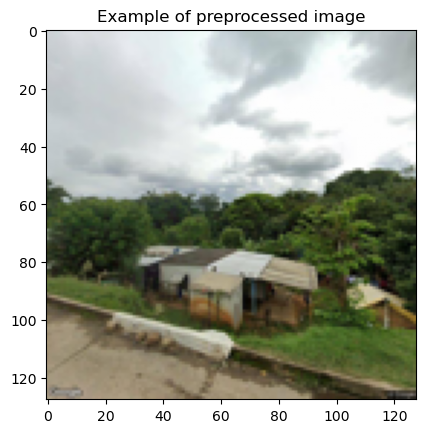

In [38]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import random

# Function to load and preprocess image (resize and normalize)
def load_and_preprocess_image(image_path):
    image = Image.open(image_path)
    image = image.resize((128, 128))
    image = np.array(image) / 255.0

    # Normalize image pixels
    return image

# Random Example image (one pixel)
preprocessed_image = load_and_preprocess_image(f'data/img/{random.randint(0, len(df_train))}.png')

# Plot image
plt.imshow(preprocessed_image)
plt.title(f'Example of preprocessed image')
plt.show()


> This function will be called for each image in the dataset when preparing the data for the model

## **3.2 Preparing input and output data**
Lets prepare the input data by collecting all images and their geolocation data (latitude and longitude) into an array of normalized pixel values.

In [39]:
# TODO: Add a Resizing layer and a Normalization layer to the model so we do not need to preprocess images.
# TODO: Use keras load_train_test_data function to load data.
# Prepare a dataframe for model input (X, y)
def prepare_model_input(df):
    X = []
    y = []

    for i, ds in df.iterrows():
        image = load_and_preprocess_image(f'data/img/{ds["filename"]}')
        X.append(image)
        y.append([ds["latitude"], ds["longitude"]])

    return np.array(X), np.array(y)

X_train, y_train = prepare_model_input(df_train)
X_test, y_test = prepare_model_input(df_test)

print(f'Prepared train data: X_train shape: {X_train.shape}, y_train shape: {y_train.shape}')
print(f'Prepared test data: X_test shape: {X_test.shape}, y_test shape: {y_test.shape}')

Prepared train data: X_train shape: (20183, 128, 128, 3), y_train shape: (20183, 2)
Prepared test data: X_test shape: (5046, 128, 128, 3), y_test shape: (5046, 2)


## **3.3 Building the regression model**

For the model we will use the following layers:

- ***Conv2D***: This layer uses filters with a 3x3 kernel size. It extracts features and patterns from the image.
- ***MaxPooling2D***: The pooling operation reduces the dimensions, which helps reduce the load on the computer hardware
- ***Flatten***: Converts the 2d feature maps into vectors (1D) so they can be used for the next layers
- ***Dense***: Layer that learns complex combinations of the found features.
- ***Dense(2)***: The final dens layer serves as a output layer for two predicted values (latitude and longitude)


### **3.3.1 Loss and activation functions**
- ***Relu activation function***: Outputs the input directly if it is positive, and outputting zero if the input is negative.
- ***Mean squared error (MSE) loss function***: Calculates the average of the squared differences between predicted and actual values

In [40]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten

# Initialize the model
model = Sequential()

# 1st Convolutional Block
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)))
model.add(MaxPooling2D(pool_size=(2, 2)))

# 2nd Convolutional Block
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# 3rd Convolutional Block
model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Flatten the feature maps to a 1D vector
model.add(Flatten())

# Fully Connected Layers (for regression)
model.add(Dense(128, activation='relu'))
model.add(Dense(64, activation='relu'))

# Output layer: 2 neurons for latitude and longitude
model.add(Dense(2))

# Compile the model
model.compile(optimizer='adam', loss='mse')

## **3.3 Training and saving the model**
The model is now ready to be trained with the training and test data. This only happens when no model exists on path `models/geohawk-regression.h5`

In [41]:
# Train the model if it does not already exist
import os

if not os.path.exists('models/geohawk-regression.h5'):
    history = model.fit(X_train , y_train, validation_data=(X_test, y_test), epochs=6, batch_size=32)
    model.save('models/geohawk-regression.h5')
else:
    print('Model already exists. Loading model and skipping training.')
    model.load_weights('models/geohawk-regression.h5')

Model already exists. Loading model and skipping training.


## **3.4 Evaluating training vs validation loss**
Plotting the training and validation loss over epochs can present some patterns. These patterns can indicate the model performance:

- Both the training and validation loss steadily decrease: Ideal situation. The model is learning and generalizing nicely
- Training loss decreases while validation loss increases: The model is learning the training model too well but struggling to generalize well. The model memorizes the training data instead of learning patterns (**Overfitting**)
- Training loss is high and validation loss is low: The model is struggling to find patterns indicating that the model is too simple (**Underfitting**)

158/158 [==============================] - 8s 51ms/step - loss: 2538.3242
Test Loss: 2538.32421875


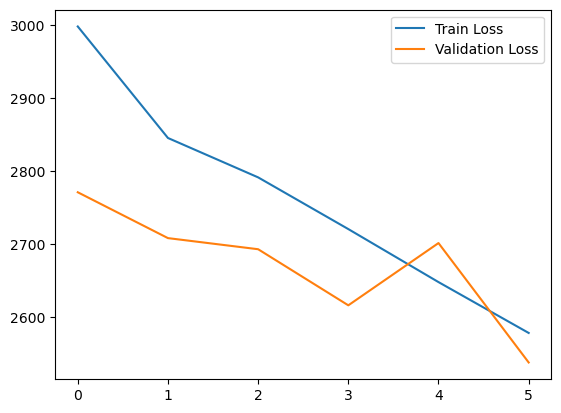

In [42]:
# Evaluate the model
test_loss = model.evaluate(X_test, y_test)
print(f'Test Loss: {test_loss}')

# Plot the loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.show()

> The validation loss steadily declines with the training loss. after 4 epochs the validation loss is higher than the training loss which could indicate **overfitting**

In [43]:
predictions = model.predict(X_test)

df_predictions = pd.DataFrame({
    'filename': df_test['filename'],
    'actual_latitude': y_test[:, 0],
    'actual_longitude': y_test[:, 1],
    'predicted_latitude': predictions[:, 0],
    'predicted_longitude': predictions[:, 1]
})

df_predictions.to_csv('demo/regression_predictions.csv', index=False)

158/158 [==============================] - 7s 44ms/step
